# 09 - Comparação de Algoritmos de Densidade: DBSCAN vs HDBSCAN

Avaliamos dois algoritmos de clustering baseados em densidade no mesmo dado
(Censo 2022 BA, espaço UMAP 2D) para justificar a escolha do HDBSCAN.

**DBSCAN**: requer um raio global `epsilon` e `min_samples`.  
**HDBSCAN**: hierárquico: adapta a escala de distância localmente por densidade.

Pergunta central: _DBSCAN consegue encontrar os mesmos tipos semânticos sem
que o analista saiba de antemão qual `epsilon` usar?_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('../outputs')

df = pd.read_parquet(OUTPUT_DIR / 'setores_features.parquet')
FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]
X = df[FEATURES].values
print(f'Setores: {len(df):,} | Features: {X.shape[1]}')

Setores: 30,355 | Features: 11


In [2]:
# Mesmos parâmetros do notebook 05
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.0, random_state=42)
X_umap = reducer.fit_transform(X)
df['umap_x'] = X_umap[:, 0]
df['umap_y'] = X_umap[:, 1]
print(f'UMAP shape: {X_umap.shape}')

UMAP shape: (30355, 2)


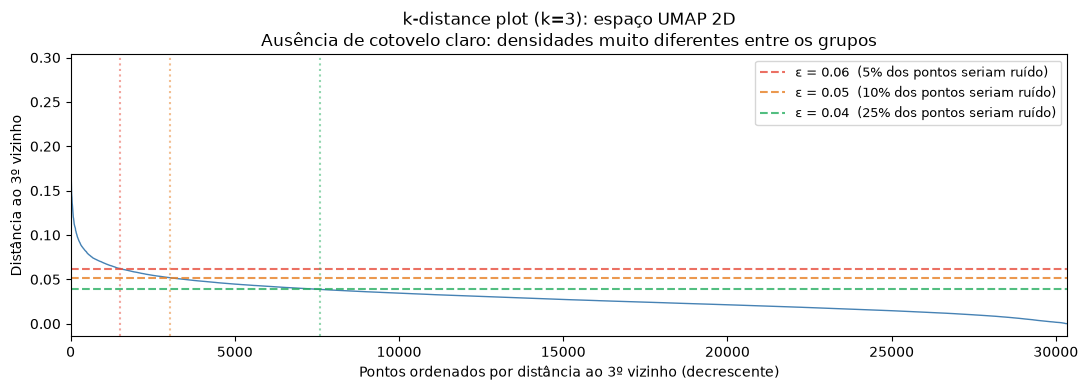

→ Sem cotovelo nítido: diferentes grupos têm densidades muito distintas.
  Qualquer epsilon escolhido será bom para alguns grupos e ruim para outros.


In [3]:
# k-distance plot: ferramenta clássica para escolher epsilon no DBSCAN
# Para k = min_samples - 1 = 2 (usaremos min_samples=3)
k = 3
nbrs = NearestNeighbors(n_neighbors=k).fit(X_umap)
dists, _ = nbrs.kneighbors(X_umap)
kdist = np.sort(dists[:, k-1])[::-1]   # distância ao k-ésimo vizinho, decrescente

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(kdist, linewidth=1, color='steelblue')

# marca percentis para mostrar a ausência de cotovelo claro
for pct, label, color in [(5, '5%', '#e74c3c'), (10, '10%', '#e67e22'), (25, '25%', '#27ae60')]:
    val = np.percentile(kdist, 100 - pct)
    ax.axhline(val, linestyle='--', color=color, alpha=0.8,
               label=f'ε = {val:.2f}  ({pct}% dos pontos seriam ruído)')
    ax.axvline(int(len(kdist) * pct / 100), linestyle=':', color=color, alpha=0.5)

ax.set_title('k-distance plot (k=3): espaço UMAP 2D\n'
             'Ausência de cotovelo claro: densidades muito diferentes entre os grupos',
             fontsize=12)
ax.set_xlabel('Pontos ordenados por distância ao 3º vizinho (decrescente)')
ax.set_ylabel('Distância ao 3º vizinho')
ax.legend(fontsize=9)
ax.set_xlim(0, len(kdist))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/kdistance_plot.png', dpi=150)
plt.show()
print('→ Sem cotovelo nítido: diferentes grupos têm densidades muito distintas.')
print('  Qualquer epsilon escolhido será bom para alguns grupos e ruim para outros.')

In [4]:
# Varredura sistemática de epsilon
epsilons = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80, 1.00, 1.50]
resultados = []

for eps in epsilons:
    labs = DBSCAN(eps=eps, min_samples=3).fit_predict(X_umap)
    nc  = len(set(labs)) - (1 if -1 in labs else 0)
    nr  = (labs == -1).mean() * 100
    mask = labs != -1
    sil = silhouette_score(X_umap[mask], labs[mask], sample_size=5000, random_state=42)           if mask.sum() > 1 and len(set(labs[mask])) > 1 else float('nan')
    # verifica se Domicílio Coletivo ainda existe (cluster com Dom.Col dominante)
    df_tmp = df.copy(); df_tmp['cluster'] = labs
    perfil = df_tmp[df_tmp['cluster'] != -1].groupby('cluster')[FEATURES].mean()
    tem_coletivo = any(row['prop_domicilio_coletivo'] == row.max() and row.max() > 1.0
                       for _, row in perfil.iterrows())
    resultados.append({'epsilon': eps, 'clusters': nc, 'ruido_pct': nr,
                       'silhouette': sil, 'dom_coletivo': tem_coletivo})

df_res = pd.DataFrame(resultados)

print('─' * 72)
print(f'{"epsilon":>8} {"clusters":>9} {"ruído%":>7} {"silhouette":>11} {"Dom.Coletivo?":>14}')
print('─' * 72)
for _, r in df_res.iterrows():
    dc = '✓' if r['dom_coletivo'] else '✗ PERDIDO'
    print(f'{r["epsilon"]:>8.2f} {int(r["clusters"]):>9} {r["ruido_pct"]:>6.1f}% '
          f'{r["silhouette"]:>11.4f} {dc:>14}')

# HDBSCAN referência
labs_h = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=3,
                          cluster_selection_method='eom').fit_predict(X_umap)
nc_h  = len(set(labs_h)) - (1 if -1 in labs_h else 0)
nr_h  = (labs_h == -1).mean() * 100
mask_h = labs_h != -1
sil_h = silhouette_score(X_umap[mask_h], labs_h[mask_h], sample_size=5000, random_state=42)
print('─' * 72)
print(f'{"HDBSCAN":>8} {nc_h:>9} {nr_h:>6.1f}% {sil_h:>11.4f} {"✓ automático":>14}')
print('─' * 72)
print()
print('→ Dom.Coletivo (hospitais/presídios, n=175) desaparece com epsilon alto:')
print('  setores institucionais ficam geograficamente próximos de setores residenciais')
print('  e são absorvidos quando o raio aumenta.')

────────────────────────────────────────────────────────────────────────
 epsilon  clusters  ruído%  silhouette  Dom.Coletivo?
────────────────────────────────────────────────────────────────────────
    0.05       898    6.8%     -0.1265              ✓
    0.10        63    0.3%     -0.2101              ✓
    0.15        27    0.0%      0.0381              ✓
    0.20        21    0.0%      0.1483              ✓
    0.30        19    0.0%      0.2258              ✓
    0.50        19    0.0%      0.2258              ✓
    0.80        16    0.0%      0.3543              ✓
    1.00        15    0.0%      0.4119              ✓
    1.50        13    0.0%      0.5289      ✗ PERDIDO
────────────────────────────────────────────────────────────────────────
 HDBSCAN        13    0.3%      0.3068   ✓ automático
────────────────────────────────────────────────────────────────────────

→ Dom.Coletivo (hospitais/presídios, n=175) desaparece com epsilon alto:
  setores institucionais ficam geografic

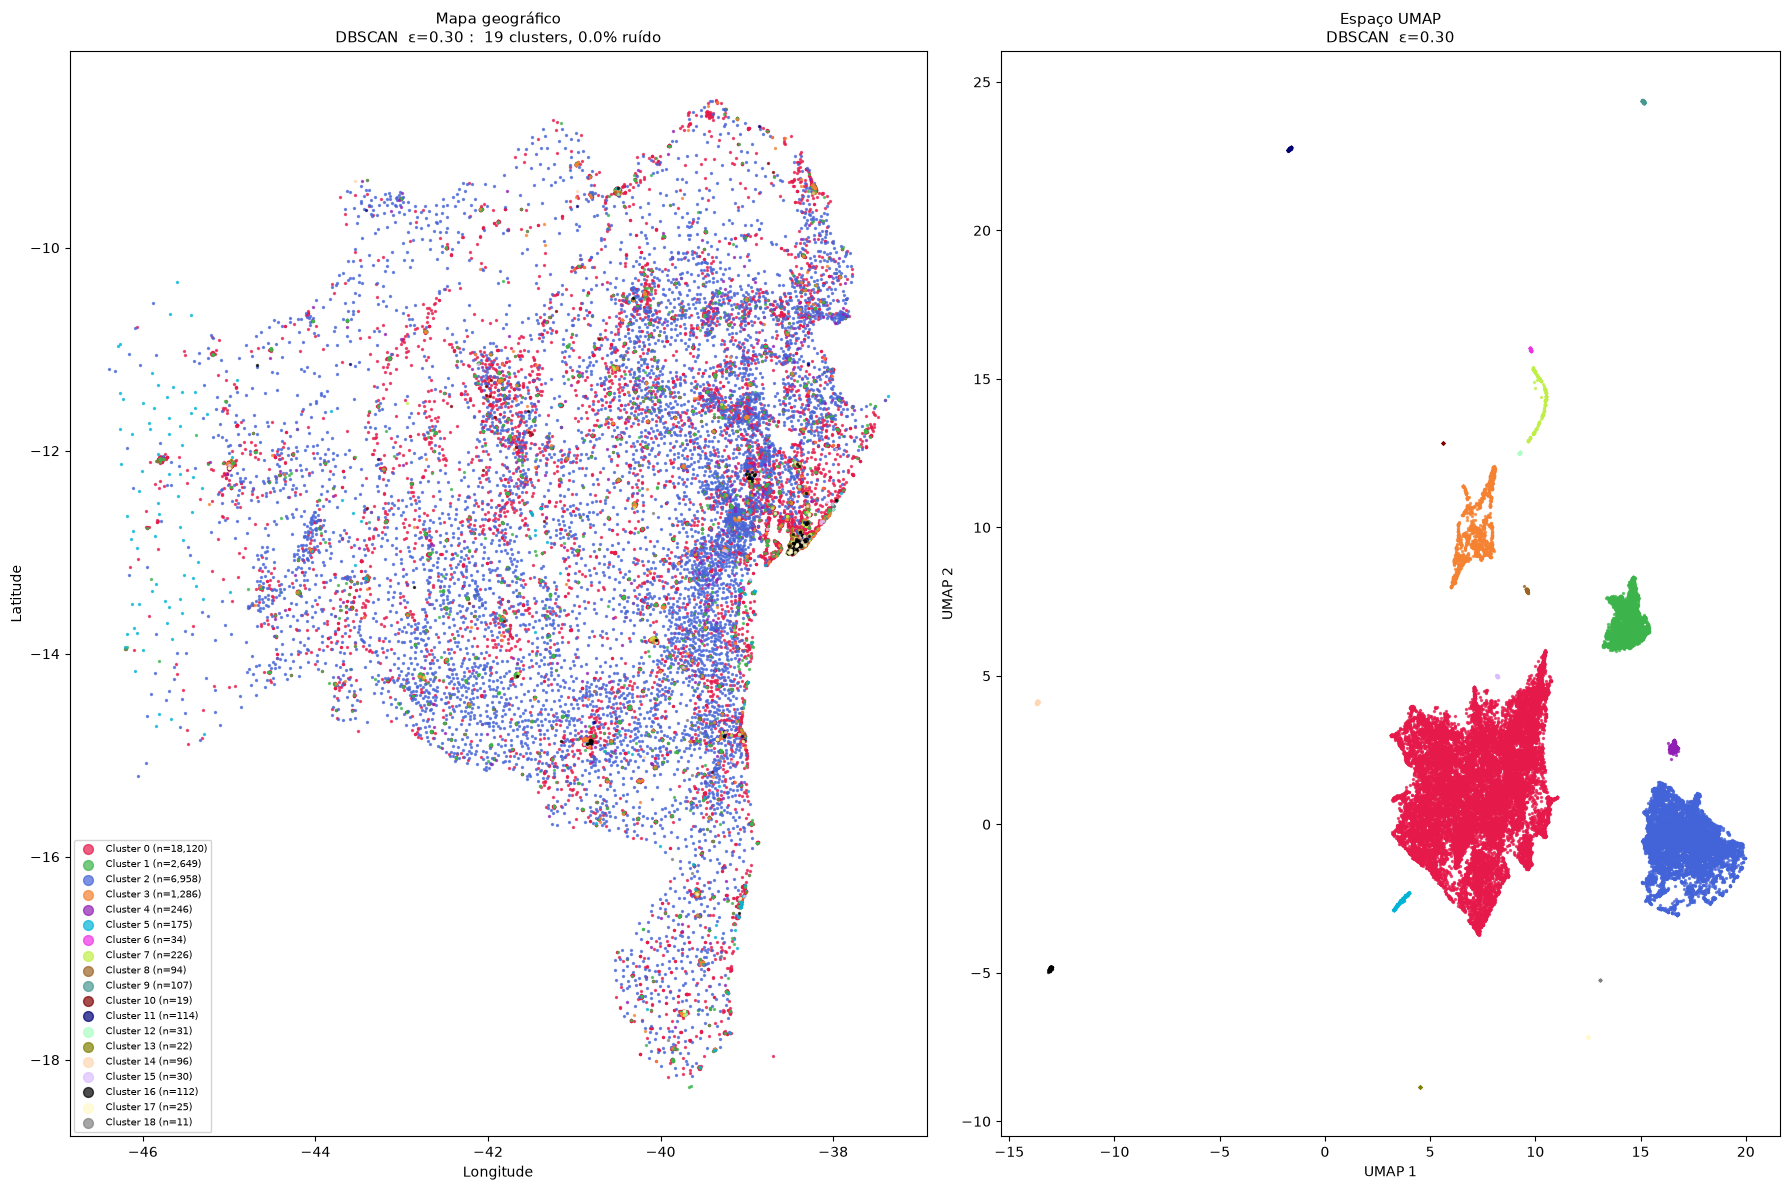

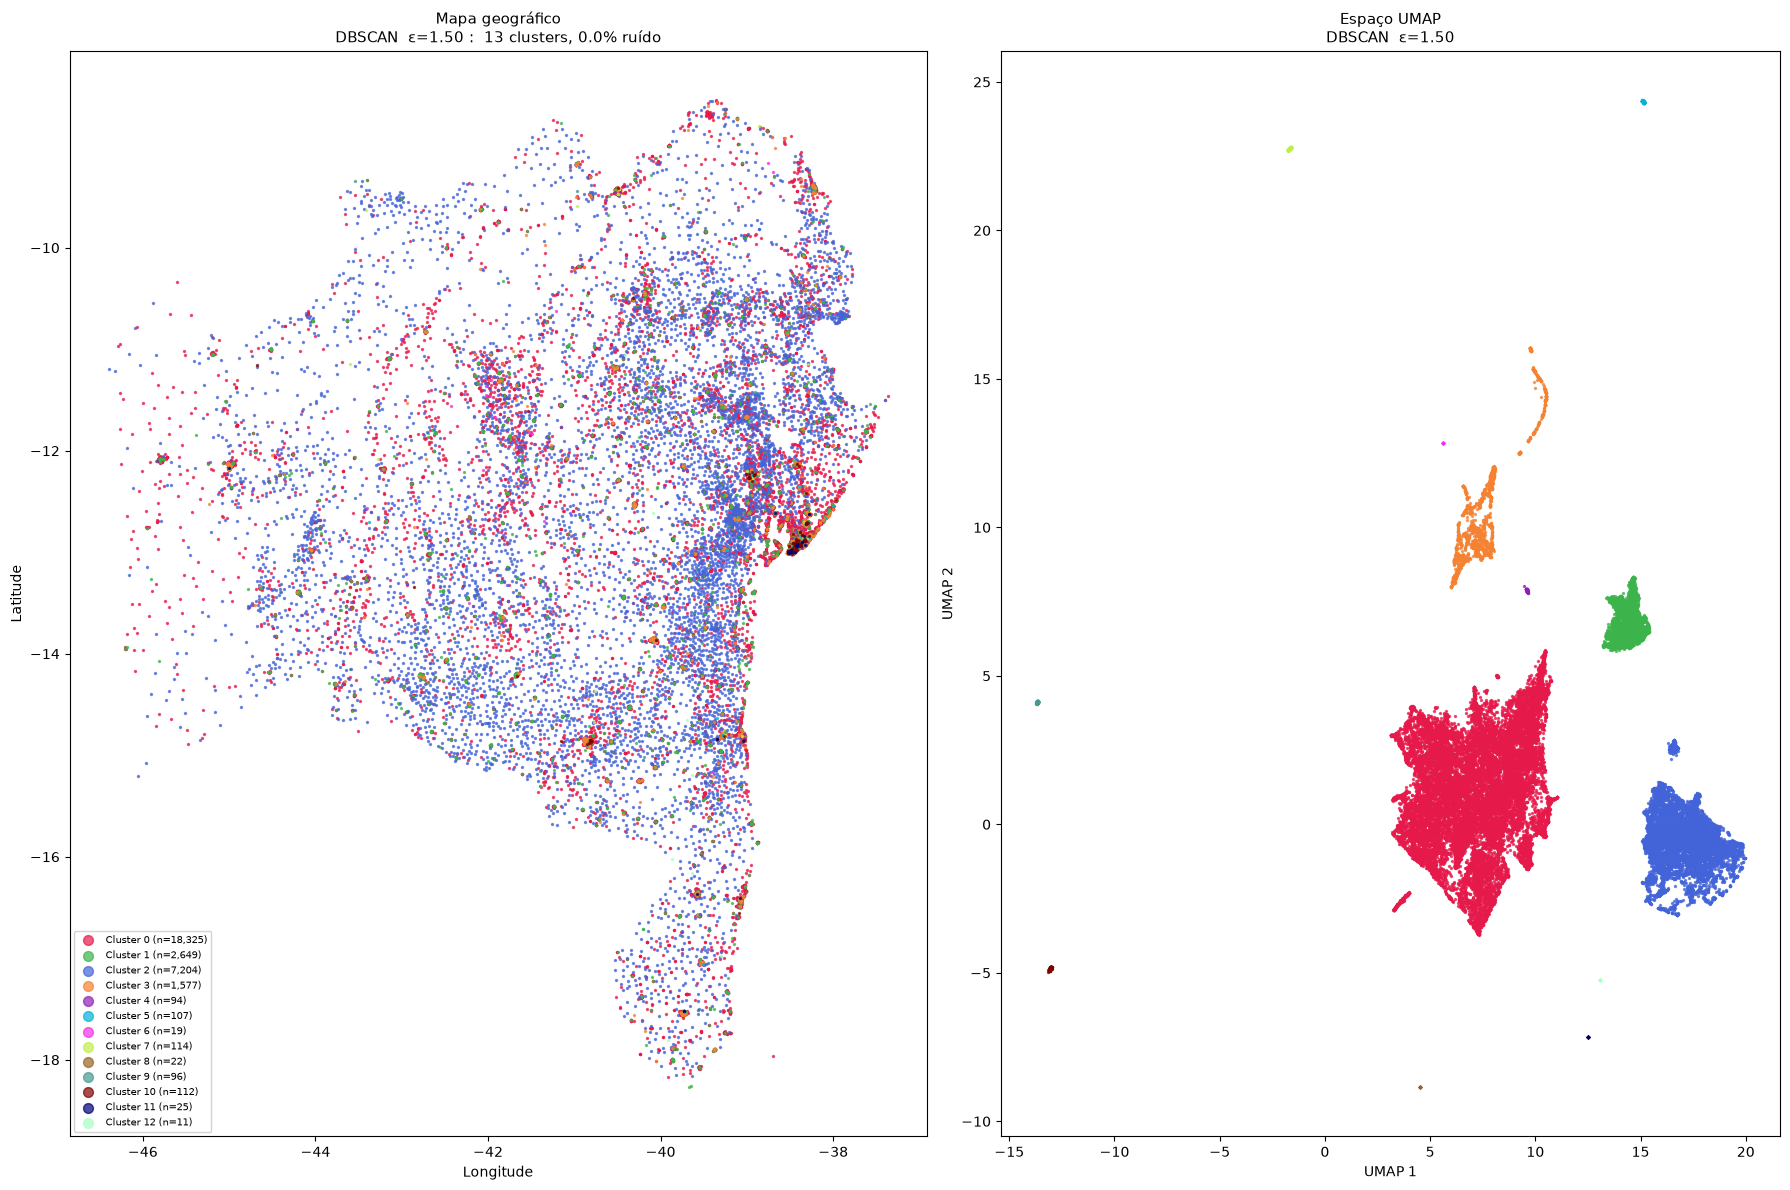

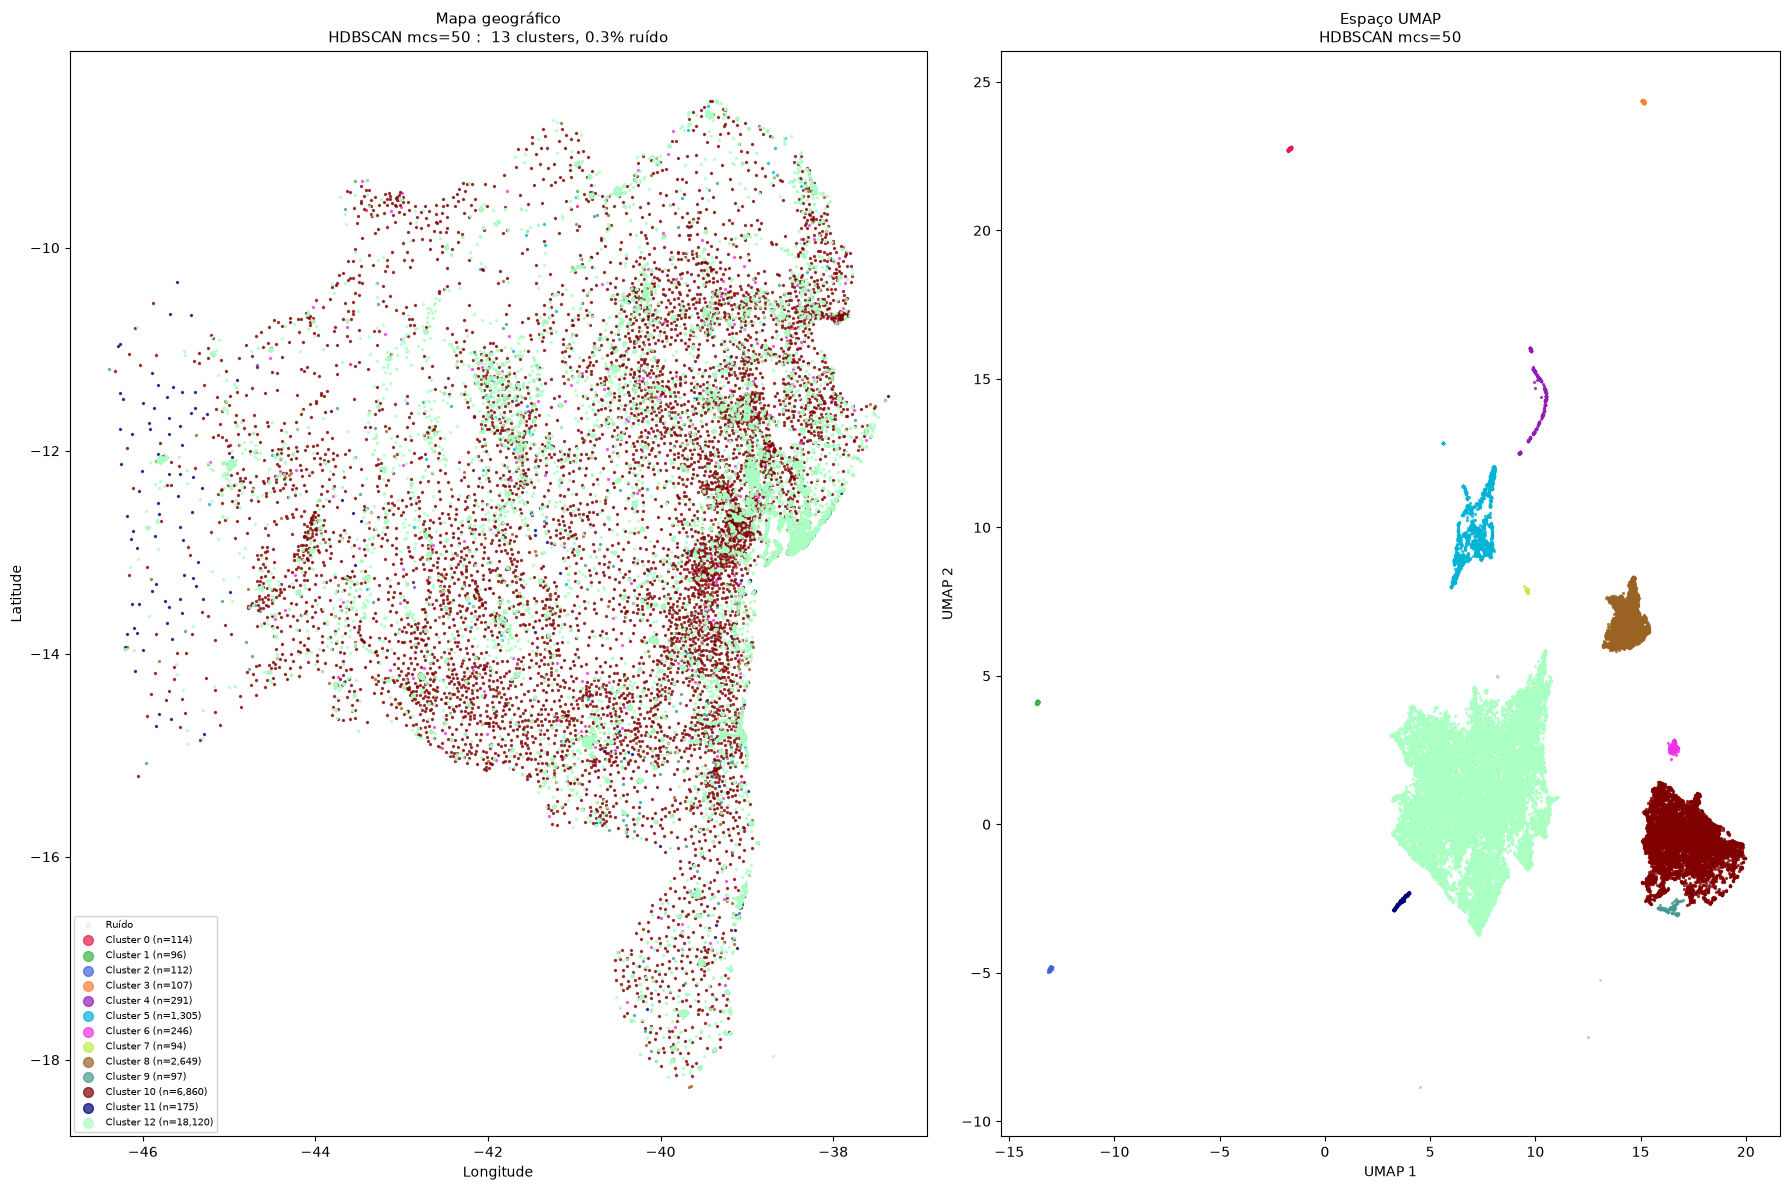

In [5]:
# Comparação visual: DBSCAN (eps=0.30) vs DBSCAN (eps=1.50) vs HDBSCAN
# eps=0.30 → mais granular, encontra Dom.Coletivo
# eps=1.50 → mesmo nº de clusters que HDBSCAN, mas perde Dom.Coletivo

configs = [
    (DBSCAN(eps=0.30, min_samples=3).fit_predict(X_umap), 'DBSCAN  ε=0.30',  'dbscan_030'),
    (DBSCAN(eps=1.50, min_samples=3).fit_predict(X_umap), 'DBSCAN  ε=1.50',  'dbscan_150'),
    (labs_h,                                               'HDBSCAN mcs=50',  'hdbscan'),
]

for labels, titulo, fname in configs:
    nc   = len(set(labels)) - (1 if -1 in labels else 0)
    nr   = (labels == -1).mean() * 100
    mask = labels != -1

    df_plot = df.copy()
    df_plot['cluster'] = labels

    # cores por cluster (palette cíclica)
    CORES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
             '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
             '#800000','#000075','#aaffc3','#808000','#ffd8b1',
             '#dcbeff','#000000','#fffac8','#808080','#ffffff']

    fig, axes = plt.subplots(1, 2, figsize=(18, 12),
                             gridspec_kw={'width_ratios': [1.1, 1]})

    #: Mapa geográfico :
    ax = axes[0]
    noise_geo = df_plot[df_plot['cluster'] == -1]
    if len(noise_geo):
        ax.scatter(noise_geo['lon_centroide'], noise_geo['lat_centroide'],
                   s=0.5, c='#cccccc', alpha=0.2, label='Ruído')
    for cid in sorted(df_plot[df_plot['cluster'] != -1]['cluster'].unique()):
        sub = df_plot[df_plot['cluster'] == cid]
        ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                   s=2, alpha=0.7, color=CORES[cid % len(CORES)],
                   label=f'Cluster {cid} (n={len(sub):,})')
    ax.set_title(f'Mapa geográfico\n{titulo} :  {nc} clusters, {nr:.1f}% ruído',
                 fontsize=11)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(markerscale=5, loc='lower left', fontsize=7,
              framealpha=0.85, ncol=1)

    #: Espaço UMAP :
    ax2 = axes[1]
    noise_u = df_plot[df_plot['cluster'] == -1]
    if len(noise_u):
        ax2.scatter(noise_u['umap_x'], noise_u['umap_y'],
                    s=0.5, c='#cccccc', alpha=0.2)
    for cid in sorted(df_plot[df_plot['cluster'] != -1]['cluster'].unique()):
        sub = df_plot[df_plot['cluster'] == cid]
        ax2.scatter(sub['umap_x'], sub['umap_y'],
                    s=2, alpha=0.7, color=CORES[cid % len(CORES)])
    ax2.set_title(f'Espaço UMAP\n{titulo}', fontsize=11)
    ax2.set_xlabel('UMAP 1'); ax2.set_ylabel('UMAP 2')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'figures/comp_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

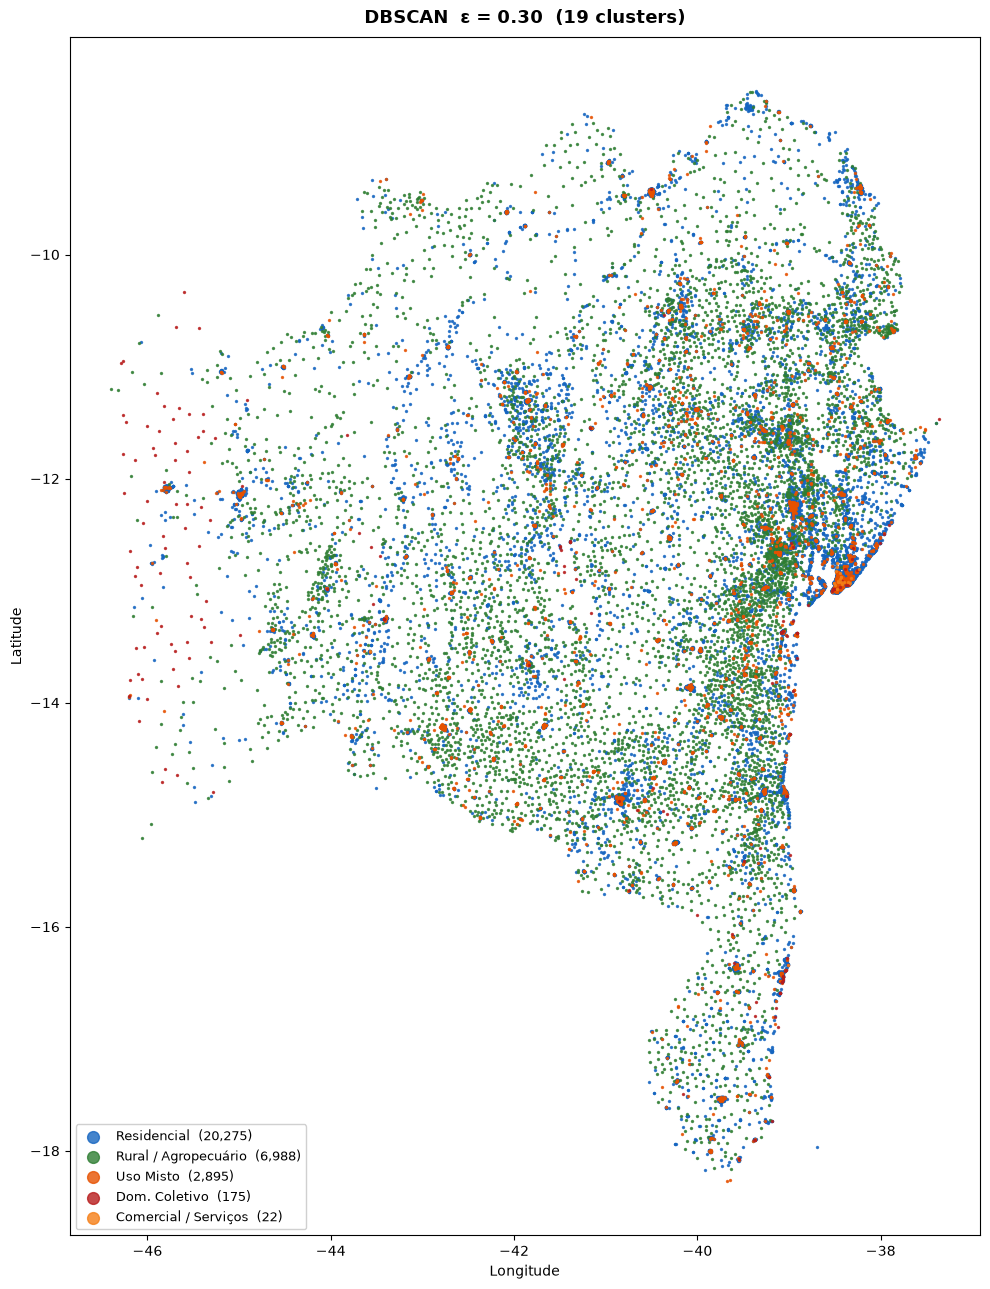

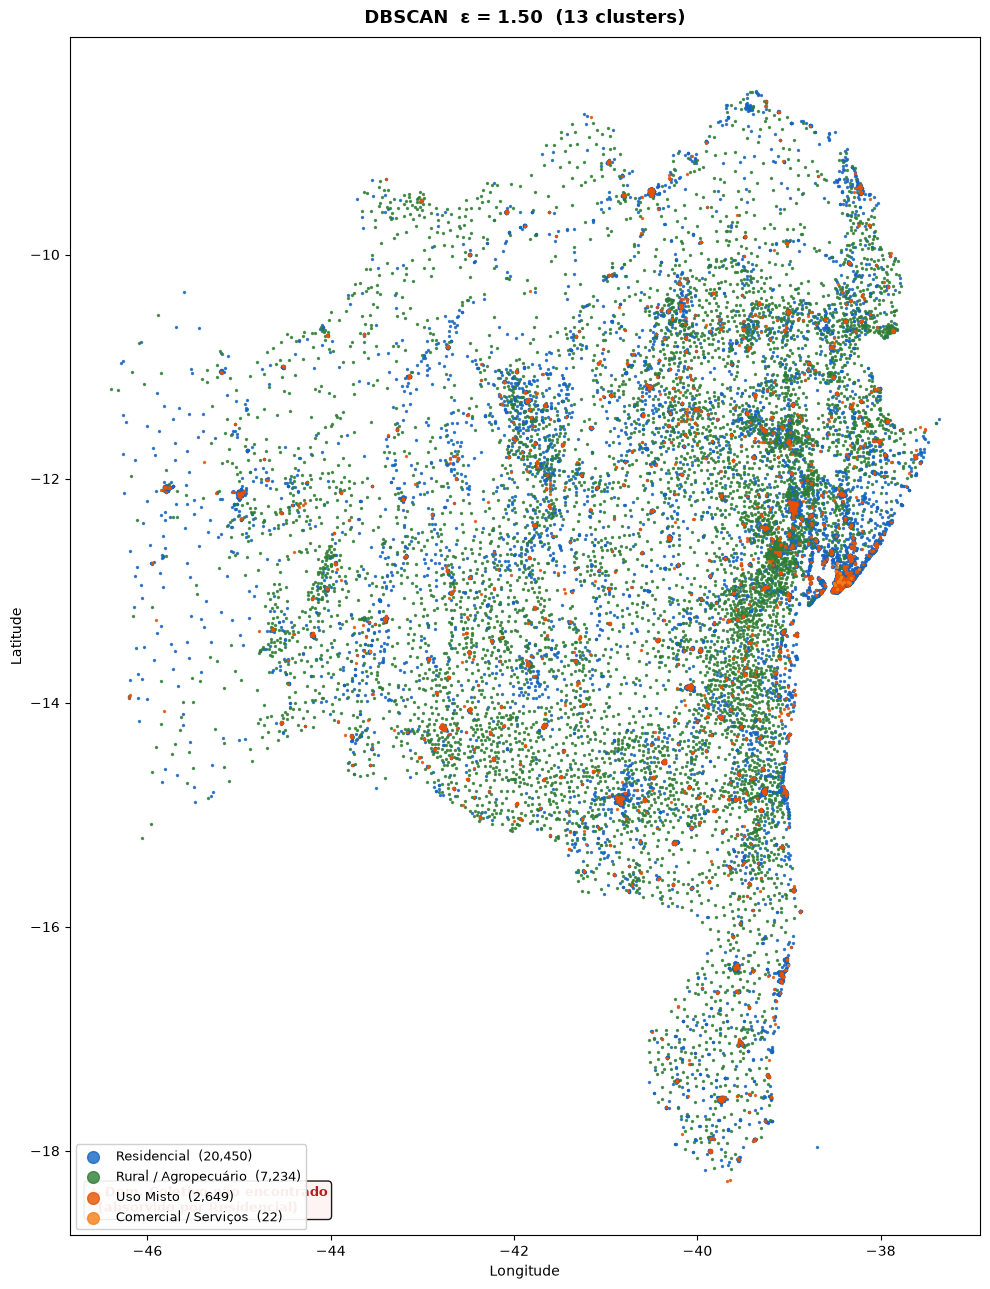

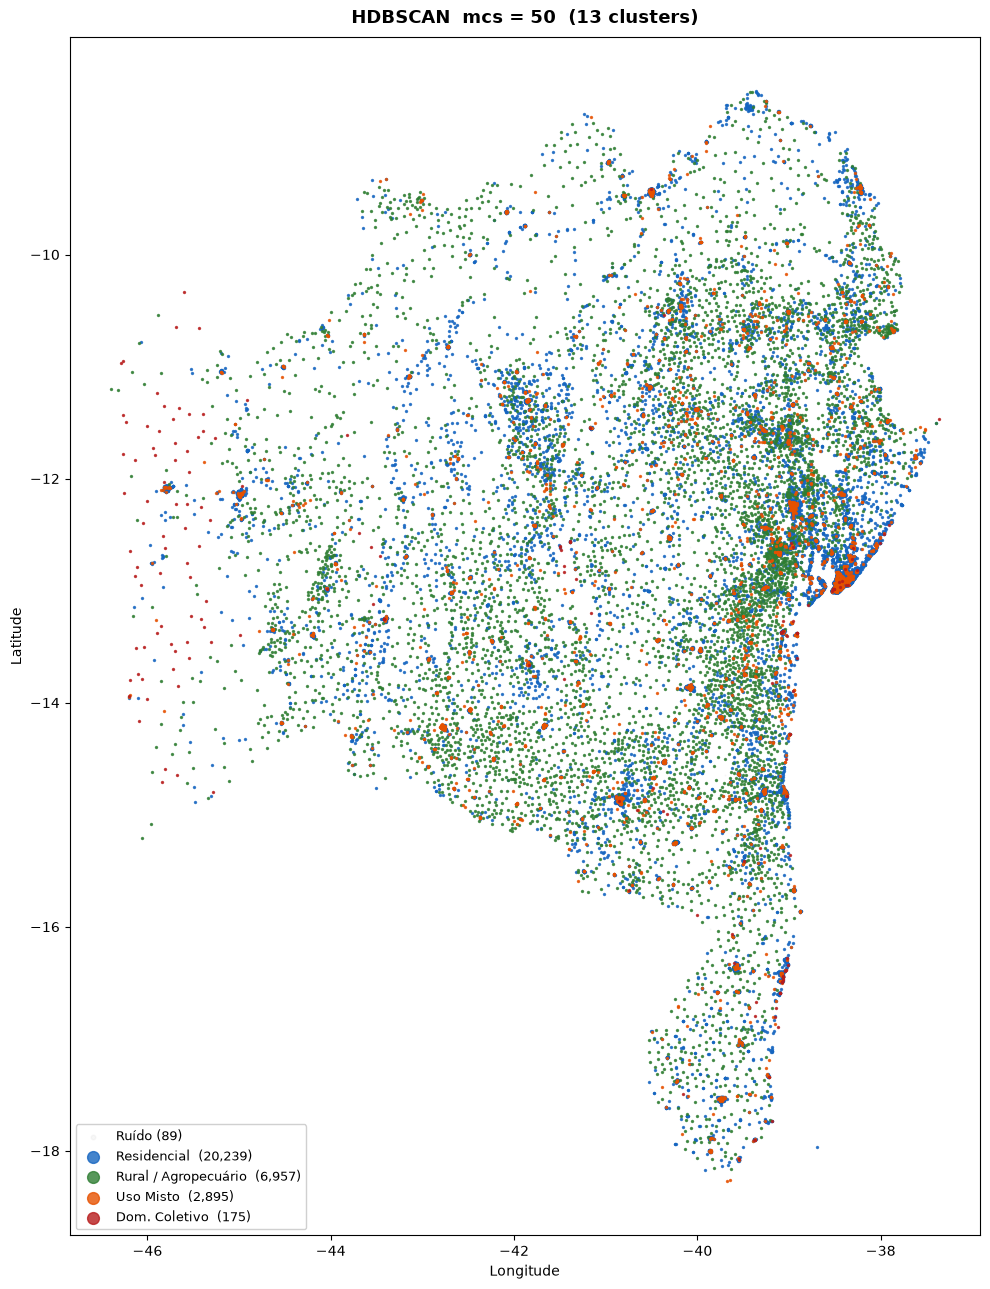

In [6]:
# Mapas geográficos coloridos por TIPO SEMÂNTICO
# Mesma cor para o mesmo tipo nos três algoritmos → comparação direta

NOMES_ESPECIE = {
    'prop_domicilio_particular':  'Residencial',
    'prop_domicilio_coletivo':    'Dom. Coletivo',
    'prop_estab_agropecuario':    'Rural / Agropecuário',
    'prop_estab_ensino':          'Educacional',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Comercial / Serviços',
    'prop_construcao':            'Em Construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Residencial',
    'prop_finalidade_comercial':  'Comercial / Serviços',
    'prop_finalidade_mista':      'Uso Misto',
}

# Paleta fixa por tipo semântico (mesma cor nos três mapas)
PALETTE_SEM = {
    'Residencial':          '#1565c0',
    'Rural / Agropecuário': '#2e7d32',
    'Uso Misto':            '#e65100',
    'Dom. Coletivo':        '#b71c1c',
    'Comercial / Serviços': '#f57f17',
    'Educacional':          '#6a1b9a',
    'Saúde':                '#00838f',
    'Em Construção':        '#795548',
    'Religioso':            '#37474f',
    'Ruído':                '#cccccc',
}

def nomeia_clusters(labels):
    """Retorna Series com nome semântico para cada setor."""
    df_tmp = df.copy()
    df_tmp['cluster'] = labels
    perfil = (df_tmp[df_tmp['cluster'] != -1]
              .groupby('cluster')[FEATURES].mean())
    nome_map = {cid: NOMES_ESPECIE[row.idxmax()] for cid, row in perfil.iterrows()}
    return df_tmp['cluster'].map(lambda x: nome_map.get(x, 'Ruído') if x != -1 else 'Ruído')

configs = [
    (DBSCAN(eps=0.30, min_samples=3).fit_predict(X_umap), 'DBSCAN  ε = 0.30  (19 clusters)'),
    (DBSCAN(eps=1.50, min_samples=3).fit_predict(X_umap), 'DBSCAN  ε = 1.50  (13 clusters)'),
    (labs_h,                                               'HDBSCAN  mcs = 50  (13 clusters)'),
]

for labels, titulo in configs:
    df_plot = df.copy()
    df_plot['tipo'] = nomeia_clusters(labels)

    tipos_presentes = [t for t in PALETTE_SEM if t in df_plot['tipo'].values]

    fig, ax = plt.subplots(figsize=(10, 13))

    # ruído primeiro (fundo)
    noise = df_plot[df_plot['tipo'] == 'Ruído']
    if len(noise):
        ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
                   s=0.3, c='#cccccc', alpha=0.15, label=f'Ruído ({len(noise):,})', zorder=1)

    for tipo in tipos_presentes:
        if tipo == 'Ruído':
            continue
        sub = df_plot[df_plot['tipo'] == tipo]
        ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                   s=2, alpha=0.8, color=PALETTE_SEM[tipo], zorder=2,
                   label=f'{tipo}  ({len(sub):,})')

    # destaca ausência do Dom. Coletivo
    if 'Dom. Coletivo' not in df_plot['tipo'].values:
        ax.text(0.02, 0.02,
                '⚠ Dom. Coletivo não encontrado\n'
                '  (absorvido por Residencial)',
                transform=ax.transAxes, fontsize=9,
                color='#b71c1c', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='#fff3f3', alpha=0.9))

    ax.legend(markerscale=6, loc='lower left', fontsize=9,
              framealpha=0.92, edgecolor='#cccccc')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()

    fname = titulo.split()[0].lower() + '_' + titulo.split('=')[-1].strip().replace('.','')             if '=' in titulo else 'hdbscan'
    plt.savefig(OUTPUT_DIR / f'figures/mapa_semantico_{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


In [7]:
# Tabela-resumo da comparação
NOMES_ESPECIE = {
    'prop_domicilio_particular':  'Residencial',
    'prop_domicilio_coletivo':    'Dom. Coletivo',
    'prop_estab_agropecuario':    'Rural / Agropecuário',
    'prop_estab_ensino':          'Educacional',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Comercial / Serviços',
    'prop_construcao':            'Em Construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Residencial',
    'prop_finalidade_comercial':  'Comercial / Serviços',
    'prop_finalidade_mista':      'Uso Misto',
}

print('Tipos semânticos encontrados por algoritmo:')
print()

for labels, titulo in [
    (DBSCAN(eps=0.30, min_samples=3).fit_predict(X_umap), 'DBSCAN ε=0.30'),
    (DBSCAN(eps=1.50, min_samples=3).fit_predict(X_umap), 'DBSCAN ε=1.50'),
    (labs_h, 'HDBSCAN mcs=50'),
]:
    df_tmp = df.copy(); df_tmp['cluster'] = labels
    nc = len(set(labels)) - (1 if -1 in labels else 0)
    perfil = df_tmp[df_tmp['cluster'] != -1].groupby('cluster')[FEATURES].mean()
    tam = df_tmp[df_tmp['cluster'] != -1].groupby('cluster').size()
    nomes = {cid: NOMES_ESPECIE[row.idxmax()] for cid, row in perfil.iterrows()}
    tipos = {}
    for cid, nome in nomes.items():
        tipos[nome] = tipos.get(nome, 0) + tam[cid]

    print(f'── {titulo} ({nc} clusters) ──────────────────────────────')
    for tipo, n in sorted(tipos.items(), key=lambda x: -x[1]):
        marker = ' ← ✗ PERDIDO' if tipo == 'Dom. Coletivo' and titulo == 'DBSCAN ε=1.50' else ''
        print(f'  {tipo:<35} {n:>6,}{marker}')
    print()

print('─' * 60)
print('Conclusão:')
print('  DBSCAN ε=0.30 → 19 clusters com micro-grupos sem sentido (n<30)')
print('  DBSCAN ε=1.50 → 13 clusters mas perde Dom. Coletivo (hospitais/presídios)')
print('  HDBSCAN       → 13 clusters, preserva Dom. Coletivo, sem micro-fragmentação')
print()
print('HDBSCAN adapta o limiar de densidade localmente:')
print('clusters compactos (residencial) e esparsos (rural) coexistem')
print('sem que o analista precise escolher um epsilon global.')

Tipos semânticos encontrados por algoritmo:

── DBSCAN ε=0.30 (19 clusters) ──────────────────────────────
  Residencial                         20,275
  Rural / Agropecuário                 6,988
  Uso Misto                            2,895
  Dom. Coletivo                          175
  Comercial / Serviços                    22

── DBSCAN ε=1.50 (13 clusters) ──────────────────────────────
  Residencial                         20,450
  Rural / Agropecuário                 7,234
  Uso Misto                            2,649
  Comercial / Serviços                    22

── HDBSCAN mcs=50 (13 clusters) ──────────────────────────────
  Residencial                         20,239
  Rural / Agropecuário                 6,957
  Uso Misto                            2,895
  Dom. Coletivo                          175

────────────────────────────────────────────────────────────
Conclusão:
  DBSCAN ε=0.30 → 19 clusters com micro-grupos sem sentido (n<30)
  DBSCAN ε=1.50 → 13 clusters mas perde Do